In [16]:
# Name: Abhishek Pandey
# Course: Advanced Big Data and Data Mining (MSCS-634-M20)
# Lab 2: Classification Using KNN and RNN Algorithms

In [17]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import RadiusNeighborsClassifier
import matplotlib.pyplot as plt


wine = load_wine()

X = wine.data      # features
y = wine.target    # class labels

df = pd.DataFrame(X, columns=wine.feature_names)
df['class'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [18]:
df['class'].value_counts()

,count
class,
1,71
0,59
2,48


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((142, 13), (36, 13))

In [20]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 1, Accuracy = 0.7778
K = 5, Accuracy = 0.7222
K = 11, Accuracy = 0.7500
K = 15, Accuracy = 0.7500
K = 21, Accuracy = 0.7778


In [21]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r)
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)

    print(f"Radius = {r}, Accuracy = {acc:.4f}")

Radius = 350, Accuracy = 0.7500
Radius = 400, Accuracy = 0.7222
Radius = 450, Accuracy = 0.7222
Radius = 500, Accuracy = 0.7222
Radius = 550, Accuracy = 0.7222
Radius = 600, Accuracy = 0.7222


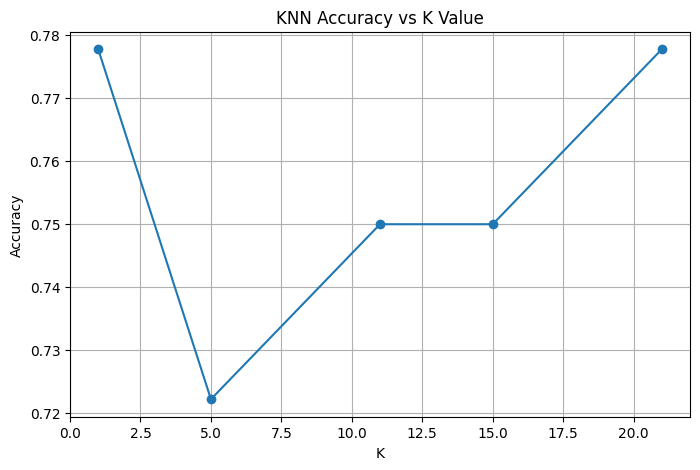

In [22]:
plt.figure(figsize=(8,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

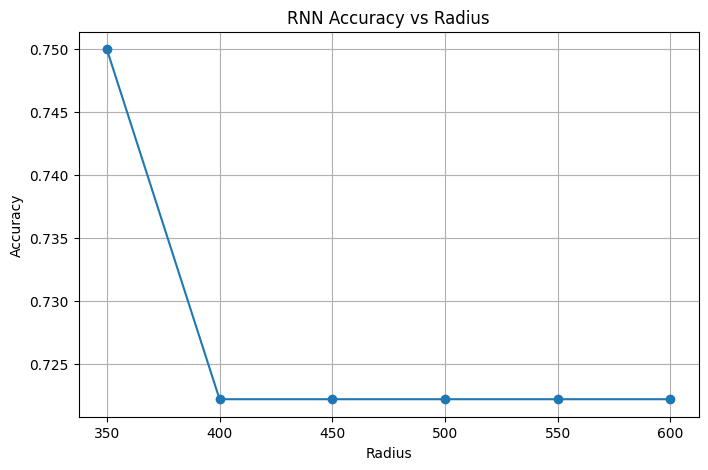

In [23]:
plt.figure(figsize=(8,5))
plt.plot(radius_values, rnn_accuracies, marker='o')
plt.title("RNN Accuracy vs Radius")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

### Model Comparison and Observations

The KNN accuracy plot shows that model performance varies with different values of k. Smaller values such as k = 1 and larger values such as k = 21 achieved the highest accuracy in this experiment, while intermediate values showed slightly lower performance. This demonstrates that parameter selection plays an important role in KNN classification.

The RNN accuracy plot shows relatively stable performance across most radius values, with the best accuracy observed at radius = 350. As the radius increases, accuracy remains mostly unchanged, indicating that RNN is less sensitive to parameter changes in this dataset.

Overall, KNN slightly outperformed RNN on the Wine dataset. KNN may be preferable when careful tuning of k is possible and local neighborhood structure is important. RNN may be useful when a meaningful distance threshold exists or when smoother decision boundaries are desired.